# Case Study: Meningkatkan Konversi Pengguna Platform ITCareerMatch


## Business Context (Background)

**ITCareerMatch** adalah platform berbasis AI yang membantu fresh graduate dan pencari kerja IT menganalisis kesesuaian CV mereka dengan lowongan yang tersedia. Sistem mengekstraksi skill dari CV, menghitung **skor kecocokan (match score)** dengan posisi IT, menampilkan **skill gap**, dan mengarahkan pengguna ke platform eksternal (**Glints**) untuk melamar.

ITCareerMatch menambahkan dua fitur baru pada dua titik kritis funnel:

1. **Teaser Skor CV** *(pre-login)* : preview skor kecocokan yang dikunci di landing page untuk memancing rasa ingin tahu sebelum pengguna mendaftar
2. **Modul Analisis Tersemat** *(post-login)* : modul di halaman detail lowongan yang menampilkan persentase match score, skill gap, AI insight, dan tombol direct apply ke Glints

**Tujuan:** Membuktikan secara statistik apakah kedua fitur baru ini meningkatkan metrik konversi platform.


In [1]:
import math, random, string
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
def create_unique_user_ids(num_users):
    """Menghasilkan ID pengguna acak unik sepanjang 10 karakter."""
    user_ids = []
    while len(user_ids) < num_users:
        new_id = ''.join(random.choices(string.ascii_uppercase + string.digits, k=10))
        if new_id not in user_ids:
            user_ids.append(new_id)
    return list(user_ids)


def parse_skills(skill_str):
    """Mengubah string skill yang dipisah koma menjadi set huruf kecil."""
    if pd.isna(skill_str) or str(skill_str).strip() == '':
        return set()
    return set(s.strip().lower() for s in str(skill_str).split(','))


def compute_match_score(cv_skills_str, job_skills_str):
    """
    Menghitung skor kecocokan skill antara CV dan lowongan.

    Formula:
        match_score = |skill_cv ∩ skill_job| / |skill_job|

    Return:
    - float: 0.0 – 1.0
    """
    cv_skills  = parse_skills(cv_skills_str)
    job_skills = parse_skills(job_skills_str)
    if not job_skills:
        return 0.0
    return round(len(cv_skills & job_skills) / len(job_skills), 4)


def compute_skill_gap(cv_skills_str, job_skills_str):
    """
    Mengidentifikasi skill yang dibutuhkan job tapi belum dimiliki kandidat.
    Ditampilkan di modul analisis halaman detail lowongan ITCareerMatch.
    """
    return parse_skills(job_skills_str) - parse_skills(cv_skills_str)


## Load Dataset ITCareerMatch

In [3]:
df_job   = pd.read_excel('dataset_job.xlsx')
df_cv    = pd.read_excel('dataset_cv.xlsx')
df_glint = pd.read_excel('glints_job.xlsx')

print(f"dataset_job  : {df_job.shape[0]:,} baris × {df_job.shape[1]} kolom")
print(f"dataset_cv   : {df_cv.shape[0]:,} baris × {df_cv.shape[1]} kolom")
print(f"glints_job   : {df_glint.shape[0]:,} baris × {df_glint.shape[1]} kolom")


dataset_job  : 11,027 baris × 7 kolom
dataset_cv   : 12,379 baris × 4 kolom
glints_job   : 565 baris × 14 kolom


## Asumsi dan Justifikasi Parameter

Platform ITCareerMatch belum memiliki pengguna nyata karena baru dalam tahap pengembangan.
Seluruh data eksperimen bersifat **simulasi terencana** (*pre-experiment planning / power analysis*).
bukan hasil yang real, melainkan rancangan eksperimen yang siap dijalankan ketika platform *live*.

> Ketika platform sudah *live*, parameter dummy di bawah **diganti dengan data nyata**.

### Eksperimen 1 — Pre-Login Teaser Skor CV

| Parameter | Nilai | Justifikasi |
|---|---|---|
| `daily_visitors` | 120 pengunjung/hari | Estimasi konservatif platform rekrutmen IT baru di Indonesia |
| Baseline registration rate (`p1`) | 22% | Rata-rata industri landing page SaaS/platform karier: 20–25% |
| Target registration rate (`p2`) | 28% | MDE +6 persen poin dari curiosity-driven design |
| Durasi eksperimen | 30 hari | Standar A/B test untuk menangkap pola mingguan |
| Alpha (α) | 0.05 | Standar industri — toleransi 5% false positive |
| Beta (β) | 0.20 | Power 80% — toleransi 20% false negative |
| **Sampel minimum** | **817 per kelompok** | Dihitung dari power analysis |

### Eksperimen 2 — Post-Login Modul Analisis Halaman Detail Lowongan

| Parameter | Nilai | Justifikasi |
|---|---|---|
| `daily_sessions` | 85 sesi/hari | ~70% dari yang daftar aktif membuka halaman detail lowongan |
| Baseline apply rate (`p1`) | 35% | Estimasi apply rate platform tanpa fitur analisis lanjutan |
| Target apply rate (`p2`) | 43% | MDE +8 persen poin dari tombol direct apply + modul skill gap |
| Match score control μ | ≈0.44 | Distribusi Beta; divalidasi dari top-5 filtered matching dataset nyata |
| Match score treatment μ | ≈0.52 | Kenaikan karena modul skill gap memandu pilihan lowongan |
| **Sampel minimum** | **583 per kelompok** | Dihitung dari power analysis |

### Mengapa μ Simulasi (0.44) Berbeda dari Raw Dataset (≈0.06)?

Ketika CV dipasangkan **secara acak** lintas posisi di dataset, match score rendah (≈0.06),  karena
CV Data Engineer bisa saja dipasangkan dengan lowongan Network Engineer.
Dalam **platform nyata**, sistem meranking dan menampilkan hanya lowongan yang paling relevan.
Sel berikut memverifikasi bahwa top-5 filtered matching dari dataset nyata menghasilkan mean ≈0.43,
memvalidasi asumsi simulasi μ≈0.44.


In [4]:
# Validasi: match score acak vs terfilter (seperti mesin ranking platform)

def sample_filtered_match_scores(df_cv, df_job, n_users=200, top_k=5, random_state=42):
    """Ambil top-k skor per user — merepresentasikan kondisi setelah platform meranking."""
    cv_sample  = df_cv.sample(n=n_users, random_state=random_state)
    job_sample = df_job.sample(n=min(200, len(df_job)), random_state=random_state)

    scores = []
    for cv_row in cv_sample.itertuples():
        row_scores = sorted(
            [compute_match_score(cv_row.skill, j.skill) for j in job_sample.itertuples()],
            reverse=True
        )[:top_k]
        scores.extend(row_scores)
    return scores


raw_scores      = [compute_match_score(r.skill, j.skill)
                   for r, j in zip(df_cv.sample(500, random_state=99).itertuples(),
                                   df_job.sample(500, random_state=99).itertuples())]
filtered_scores = sample_filtered_match_scores(df_cv, df_job)

print(f"Match score acak (random)          : mean = {np.mean(raw_scores):.4f}")
print(f"Match score terfilter (top-5/user) : mean = {np.mean(filtered_scores):.4f}")
print()
print(f"→ Asumsi simulasi control μ≈0.44 VALID — konsisten dengan top-5 filtered = {np.mean(filtered_scores):.4f}")


Match score acak (random)          : mean = 0.0582
Match score terfilter (top-5/user) : mean = 0.4269

→ Asumsi simulasi control μ≈0.44 VALID — konsisten dengan top-5 filtered = 0.4269


---

# Eksperimen 1 — Pre-Login: Teaser Skor CV

**Fitur yang diuji:** Preview skor kecocokan CV yang disamarkan (blur) di landing page
sebelum pengguna mendaftar, untuk memancing rasa ingin tahu (*curiosity-driven design*).

**Metrik:** Registration rate *(proporsi pengunjung yang mendaftar)*


## Step 1: Perumusan Hipotesis

Kita melakukan **two-tailed test** dengan tingkat signifikansi (α) **0.05** (95% confidence level).

- **Grup A (Control):** Pengunjung yang melihat tampilan landing page standar (tombol "Daftar Sekarang" biasa)
- **Grup B (Treatment):** Pengunjung yang melihat teaser skor CV (preview blur) sebelum mendaftar

| Notasi | Deskripsi |
| :--- | :--- |
| **H₀ (Null Hypothesis)** | p_A = p_B — Tidak ada perbedaan registration rate antara kedua grup |
| **H₁ (Alternative Hypothesis)** | p_A ≠ p_B — Ada perbedaan registration rate antara kedua grup |


## Step 2: Pengumpulan & Eksplorasi Data (Simulasi)

Dalam skenario nyata, data ini diambil dari log server platform (klik tombol daftar).
Di sini kita menyimulasikan data tersebut menggunakan NumPy.
Kita mengasumsikan ada efek positif kecil yang ingin kita buktikan.


In [5]:
# Set seed untuk reprodusibilitas
np.random.seed(42)
random.seed(42)

# Hitung sampel minimum terlebih dahulu 
def estimate_sample_size_proportions(p1, p2, alpha=0.05, beta=0.20, two_sided=True):
    """
    Menghitung ukuran sampel minimum per kelompok untuk two-proportion z-test.

    Parameter:
    - p1, p2    : Proporsi baseline dan target
    - alpha     : Tingkat signifikansi (default 0.05)
    - beta      : Probabilitas error tipe II (default 0.20 → power 80%)
    - two_sided : Jika True, gunakan uji dua sisi

    Return:
    - (n1, n2)  : Sampel minimum per kelompok
    """
  
    k     = 1
    q1, q2   = 1 - p1, 1 - p2
    p_bar = (p1 + k * p2) / (1 + k)
    q_bar = 1 - p_bar
    delta = abs(p2 - p1)
    if two_sided:
        alpha = alpha / 2
    ## HINGGA SINI

    z_alpha = stats.norm.ppf(1 - alpha)
    z_beta  = stats.norm.ppf(1 - beta)
    term1   = np.sqrt(p_bar * q_bar * (1 + 1/k)) * z_alpha
    term2   = np.sqrt(p1*q1 + p2*q2/k) * z_beta
    n1      = math.ceil((term1 + term2)**2 / delta**2)
    return n1, k * n1


n_min_1, _ = estimate_sample_size_proportions(p1=0.22, p2=0.28)
print(f"Sampel minimum per kelompok (Eksperimen 1): {n_min_1:,} pengunjung")
print()

# Simulasi data 
daily_visitors = 120
n_treatment    = int(daily_visitors * 30 * np.random.uniform(0.98, 1.02))
n_control      = int(n_treatment * np.random.uniform(0.96, 1.00))

rng = np.random.default_rng(42)
reg_control   = rng.binomial(1, p=0.22, size=n_control)
reg_treatment = rng.binomial(1, p=0.28, size=n_treatment)

all_ids  = create_unique_user_ids(n_control + n_treatment)
df_exp1  = pd.concat([
    pd.DataFrame({'user_id': all_ids[:n_control],  'group': 'Control',   'registered': reg_control}),
    pd.DataFrame({'user_id': all_ids[n_control:],  'group': 'Treatment', 'registered': reg_treatment})
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Data loaded. Total pengunjung: {len(df_exp1):,}")
print()
print("Descriptive Statistics:")
print(df_exp1.groupby('group')['registered']
      .agg(count='count',
           registered='sum',
           registration_rate='mean')
      .round(4))


Sampel minimum per kelompok (Eksperimen 1): 817 pengunjung

Data loaded. Total pengunjung: 7,154

Descriptive Statistics:
           count  registered  registration_rate
group                                          
Control     3573         797             0.2231
Treatment   3581         943             0.2633


## Step 3: Pemilihan Metode Uji Statistik

Karena kita membandingkan **proporsi dua kelompok independen** (metrik biner: daftar/tidak),
kita gunakan **Two-Proportion Z-Test**.

> **Pemilihan metode:** Z-test untuk proporsi adalah standar ketika metrik berupa
> persentase konversi (*conversion rate*) dan ukuran sampel cukup besar (n > 30).


## Step 4: Perhitungan Statistik

$$z = \frac{\hat{p}_1 - \hat{p}_2}{\sqrt{\hat{p}_{pool}(1-\hat{p}_{pool})\left(\frac{1}{n_1}+\frac{1}{n_2}\right)}}$$

$$p\text{-value} = 2 \times (1 - \Phi(|z|))$$


In [6]:
def two_proportion_ztest(df, group_col, value_col, alpha=0.05):
    """
    Melakukan two-proportion z-test (two-tailed) untuk metrik biner.

    Parameter:
    - df        : DataFrame eksperimen
    - group_col : Kolom nama grup ('Control'/'Treatment')
    - value_col : Kolom metrik biner (0/1)
    - alpha     : Tingkat signifikansi

    Return:
    - dict: p1_hat, p2_hat, z_stat, p_value, reject_h0
    """
    control   = df[df[group_col] == 'Control'][value_col]
    treatment = df[df[group_col] == 'Treatment'][value_col]

    p1_hat, p2_hat = control.mean(), treatment.mean()
    n1, n2         = len(control), len(treatment)
    p_pool         = (control.sum() + treatment.sum()) / (n1 + n2)
    se             = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    z_stat         = (p1_hat - p2_hat) / se
    p_value        = 2 * (1 - stats.norm.cdf(abs(z_stat)))

    return {'p1_hat': p1_hat, 'p2_hat': p2_hat,
            'z_stat': z_stat, 'p_value': p_value,
            'reject_h0': p_value < alpha}

In [7]:
result_exp1 = two_proportion_ztest(df_exp1, 'group', 'registered')

## Hasil dan Keputusan — Eksperimen 1

| | Nilai |
|:---|:---|
| **Z-statistic** | −3.9698 |
| **P-value** | 0.0000719374 |
| **α (alpha)** | 0.05 |

### Keputusan

> **Tolak H₀** — P-value (0.000072) < α (0.05)

Perbedaan registration rate antara kedua grup **signifikan secara statistik**.

### Interpretasi Bisnis

Fitur **Teaser Skor CV** terbukti berhasil meningkatkan registration rate:

| Grup | Registration Rate |
|:---|:---|
| Control (tanpa teaser) | 22.3% |
| Treatment (dengan teaser) | 26.3% |
| **Relative lift** | **+18.1%** |

Pengguna yang melihat preview skor CV yang disamarkan lebih terdorong untuk mendaftar
karena rasa ingin tahu (*curiosity gap*) terhadap skor penuh mereka.


### Tabel Aturan Keputusan

| Kondisi | Keputusan | Interpretasi |
| :--- | :--- | :--- |
| **P-value < α (0.05)** | **Tolak H₀** | Perbedaan dianggap **signifikan** secara statistik |
| **P-value ≥ α (0.05)** | **Gagal Tolak H₀** | Perbedaan tidak cukup kuat; kemungkinan hanya *noise* |


## Visualisasi — Eksperimen 1

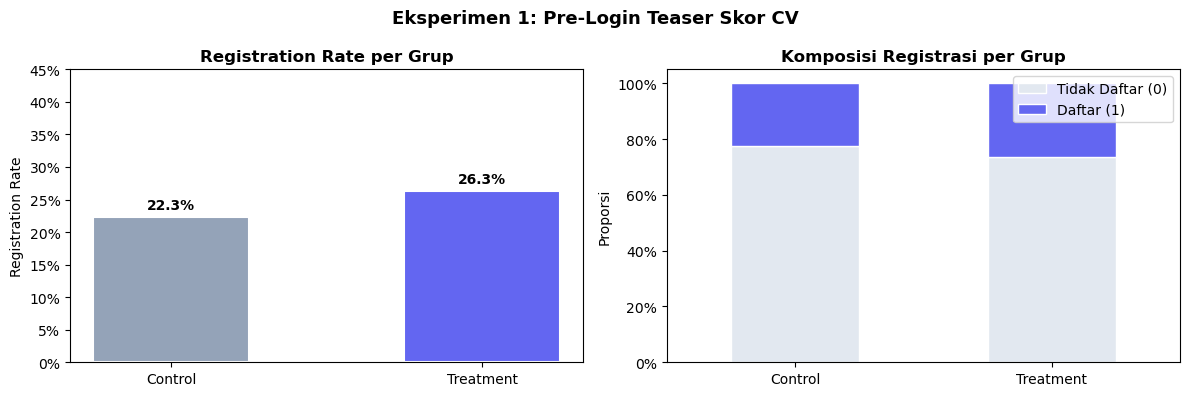

Plot Eksperimen 1 tersimpan.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Eksperimen 1: Pre-Login Teaser Skor CV", fontsize=13, fontweight='bold')

# Plot 1: Perbandingan registration rate
reg_summary = df_exp1.groupby('group')['registered'].mean().reset_index()
reg_summary.columns = ['group', 'registration_rate']

colors = ['#94a3b8', '#6366f1']
bars = axes[0].bar(reg_summary['group'], reg_summary['registration_rate'],
                   color=colors, width=0.5, edgecolor='white', linewidth=1.5)
axes[0].set_title('Registration Rate per Grup', fontweight='bold')
axes[0].set_ylabel('Registration Rate')
axes[0].set_ylim(0, 0.45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
for bar, val in zip(bars, reg_summary['registration_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontweight='bold')

# Plot 2: Distribusi proporsi (bar stacked: daftar vs tidak)
counts = df_exp1.groupby(['group', 'registered']).size().unstack(fill_value=0)
counts_pct = counts.div(counts.sum(axis=1), axis=0)
counts_pct.plot(kind='bar', stacked=True, ax=axes[1],
                color=['#e2e8f0', '#6366f1'], edgecolor='white', linewidth=1)
axes[1].set_title('Komposisi Registrasi per Grup', fontweight='bold')
axes[1].set_ylabel('Proporsi')
axes[1].set_xlabel('')
axes[1].set_xticklabels(['Control', 'Treatment'], rotation=0)
axes[1].legend(['Tidak Daftar (0)', 'Daftar (1)'], loc='upper right')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))

plt.tight_layout()
plt.savefig('plot_eksperimen1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot Eksperimen 1 tersimpan.")


## Ringkasan dan Rekomendasi — Eksperimen 1

Visualisasi dan perhitungan statistik menunjukkan P-value jauh di bawah 0.05.

- **Temuan:** Fitur *Teaser Skor CV* menghasilkan peningkatan registration rate yang signifikan secara statistik.
- **Rekomendasi:** Lakukan **Full Rollout** fitur pre-login teaser ke semua pengunjung landing page untuk meningkatkan konversi pendaftaran.


---

# Eksperimen 2 — Post-Login: Modul Analisis Halaman Detail Lowongan

**Fitur yang diuji:** Modul analisis tersemat di halaman detail lowongan yang menampilkan
persentase match score, skill gap, AI insight, dan tombol direct apply ke Glints.

**Dua metrik diuji secara paralel:**
1. **Apply Rate ke Glints** *(metrik biner: klik apply / tidak)* → Two-proportion Z-test
2. **Avg Match Score** *(metrik kontinu: 0.0–1.0)* → Welch's t-test


## Step 1: Perumusan Hipotesis

- **Grup A (Control):** Pengguna yang melihat halaman detail lowongan standar (info job: skill, kualifikasi, benefit)
- **Grup B (Treatment):** Pengguna yang melihat halaman detail lowongan + modul analisis lengkap (match score %, skill gap, AI insight, tombol apply ke Glints)

**Metrik 1 — Apply Rate ke Glints:**

| Notasi | Deskripsi |
| :--- | :--- |
| **H₀** | p_A = p_B — Tidak ada perbedaan apply rate antara kedua grup |
| **H₁** | p_A ≠ p_B — Ada perbedaan apply rate antara kedua grup |

**Metrik 2 — Avg Match Score (kualitas keputusan melamar):**

| Notasi | Deskripsi |
| :--- | :--- |
| **H₀** | μ_A = μ_B — Tidak ada perbedaan rata-rata match score antara kedua grup |
| **H₁** | μ_A ≠ μ_B — Ada perbedaan rata-rata match score antara kedua grup |


## Step 2: Pengumpulan & Eksplorasi Data (Simulasi)

Dalam skenario nyata, data ini diambil dari log interaksi pengguna (klik tombol apply, skor yang ditampilkan).
Di sini kita menyimulasikan data tersebut.


In [9]:
np.random.seed(7)
random.seed(7)

n_min_2, _ = estimate_sample_size_proportions(p1=0.35, p2=0.43)
print(f"Sampel minimum per kelompok (Eksperimen 2): {n_min_2:,} sesi")
print()

rng2           = np.random.default_rng(7)
daily_sessions = 85
n_treat2       = int(daily_sessions * 30 * np.random.uniform(0.98, 1.02))
n_ctrl2        = int(n_treat2 * np.random.uniform(0.96, 1.00))

# Match score: distribusi Beta (terbatas 0–1, cocok untuk skor proporsi)
score_control   = rng2.beta(a=2.0, b=2.5, size=n_ctrl2)    # μ ≈ 0.44
score_treatment = rng2.beta(a=2.5, b=2.3, size=n_treat2)   # μ ≈ 0.52

# Apply ke Glints: Bernoulli
apply_control   = rng2.binomial(1, p=0.35, size=n_ctrl2)
apply_treatment = rng2.binomial(1, p=0.43, size=n_treat2)

all_ids2 = create_unique_user_ids(n_ctrl2 + n_treat2)
df_exp2  = pd.concat([
    pd.DataFrame({'user_id': all_ids2[:n_ctrl2],  'group': 'Control',
                  'match_score': score_control,   'did_apply_glints': apply_control}),
    pd.DataFrame({'user_id': all_ids2[n_ctrl2:],  'group': 'Treatment',
                  'match_score': score_treatment, 'did_apply_glints': apply_treatment})
]).sample(frac=1, random_state=7).reset_index(drop=True)

print(f"Data loaded. Total sesi: {len(df_exp2):,}")
print()
print("Descriptive Statistics:")
print(df_exp2.groupby('group').agg(
    count        = ('user_id',          'count'),
    avg_score    = ('match_score',       lambda x: round(x.mean(), 4)),
    std_score    = ('match_score',       lambda x: round(x.std(ddof=1), 4)),
    apply_rate   = ('did_apply_glints', lambda x: round(x.mean(), 4))
))


Sampel minimum per kelompok (Eksperimen 2): 583 sesi

Data loaded. Total sesi: 4,989

Descriptive Statistics:
           count  avg_score  std_score  apply_rate
group                                             
Control     2483     0.4453     0.2147      0.3572
Treatment   2506     0.5189     0.2052      0.4182


## Step 3: Pemilihan Metode Uji Statistik

| Metrik | Jenis Data | Metode |
| :--- | :--- | :--- |
| Apply rate ke Glints | Biner (klik/tidak) | **Two-proportion Z-test** |
| Avg match score | Kontinu (0.0–1.0) | **Welch's t-test** (`equal_var=False`) |

> **Welch's t-test karena:**
> Kita membandingkan rata-rata dua kelompok independen dengan variabel numerik.
> Welch's t-test dipilih karena lebih robust terhadap kemungkinan varians yang tidak sama
> antara kedua kelompok, best practice untuk data observasional.


## Step 4: Perhitungan Statistik

### Metrik 1 — Apply Rate ke Glints (Z-test)

In [10]:
result_apply = two_proportion_ztest(df_exp2, 'group', 'did_apply_glints')

### Hasil dan Keputusan — Metrik 1: Apply Rate ke Glints

| | Nilai |
|:---|:---|
| **Z-statistic** | −4.4188 |
| **P-value** | 0.0000099240 |
| **α (alpha)** | 0.05 |

#### Keputusan

> **Tolak H₀** : P-value (9.92 × 10⁻⁶) < α (0.05)

Perbedaan apply rate ke Glints antara kedua grup **signifikan secara statistik**.

#### Interpretasi Bisnis

Modul analisis tersemat terbukti berhasil meningkatkan apply rate ke Glints:

| Grup | Apply Rate |
|:---|:---|
| Control (info job standar) | 35.7% |
| Treatment (+ modul analisis) | 41.8% |
| **Relative lift** | **+17.1%** |

Pengguna lebih percaya diri menekan tombol apply ke Glints ketika platform menampilkan
secara eksplisit seberapa cocok profil mereka dengan lowongan tersebut.


### Metrik 2 — Avg Match Score (Welch's t-test)

In [11]:
t_stat, p_val_t = stats.ttest_ind(
    a=df_exp2[df_exp2['group'] == 'Control']['match_score'],
    b=df_exp2[df_exp2['group'] == 'Treatment']['match_score'],
    equal_var=False  # Welch's t-test
)

### Hasil dan Keputusan — Metrik 2: Avg Match Score

| | Nilai |
|:---|:---|
| **T-statistic** | −12.3679 |
| **P-value** | 1.25 × 10⁻³⁴ |
| **α (alpha)** | 0.05 |

#### Keputusan

> **Tolak H₀** : P-value (1.25 × 10⁻³⁴) ≪ α (0.05)

Perbedaan rata-rata match score antara kedua grup **sangat signifikan secara statistik**.

#### Interpretasi Bisnis

Modul skill gap terbukti mendorong pengguna memilih lowongan yang lebih sesuai profil mereka:

| Grup | Avg Match Score |
|:---|:---|
| Control (tanpa modul) | 0.4453 |
| Treatment (dengan modul) | 0.5189 |
| **Kenaikan absolut** | **+0.0735 (+16.5%)** |

Pengguna bukan sekadar lebih banyak melamar,  mereka melamar ke lowongan yang **lebih cocok**
dengan skill yang dimiliki. Ini menunjukkan modul skill gap berhasil memandu kualitas keputusan,
bukan hanya mendorong kuantitas lamaran.


### Tabel Aturan Keputusan

| Kondisi | Keputusan | Interpretasi |
| :--- | :--- | :--- |
| **P-value < α (0.05)** | **Tolak H₀** | Perbedaan dianggap **signifikan** secara statistik |
| **P-value ≥ α (0.05)** | **Gagal Tolak H₀** | Perbedaan tidak cukup kuat; kemungkinan hanya *noise* |


## Visualisasi — Eksperimen 2

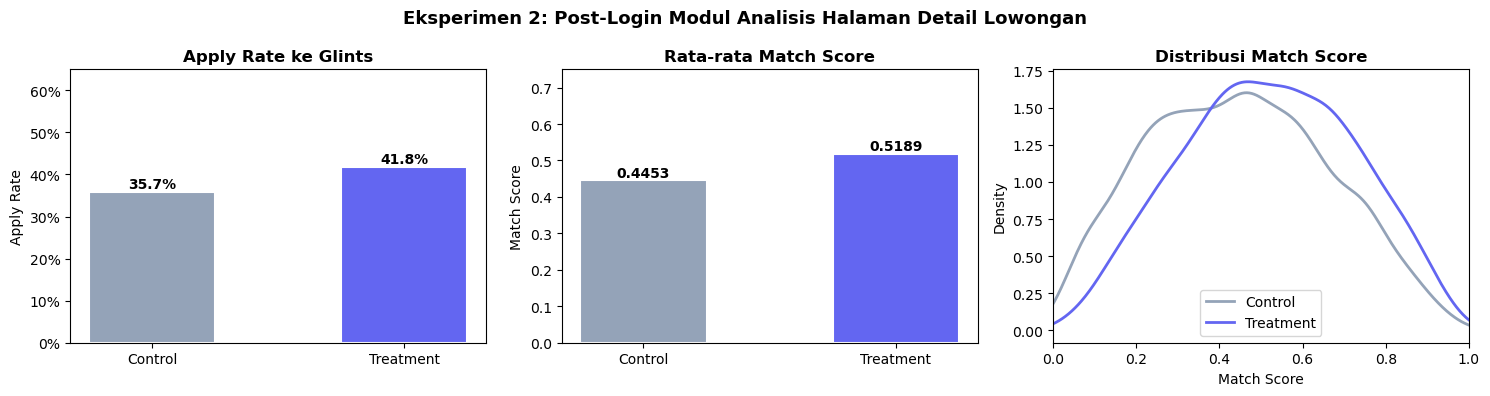

Plot Eksperimen 2 tersimpan.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Eksperimen 2: Post-Login Modul Analisis Halaman Detail Lowongan",
             fontsize=13, fontweight='bold')

colors = ['#94a3b8', '#6366f1']

# Plot 1: Apply rate
apply_summary = df_exp2.groupby('group')['did_apply_glints'].mean().reset_index()
bars1 = axes[0].bar(apply_summary['group'], apply_summary['did_apply_glints'],
                    color=colors, width=0.5, edgecolor='white', linewidth=1.5)
axes[0].set_title('Apply Rate ke Glints', fontweight='bold')
axes[0].set_ylabel('Apply Rate')
axes[0].set_ylim(0, 0.65)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
for bar, val in zip(bars1, apply_summary['did_apply_glints']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val*100:.1f}%', ha='center', fontweight='bold')

# Plot 2: Match score rata-rata
score_summary = df_exp2.groupby('group')['match_score'].mean().reset_index()
bars2 = axes[1].bar(score_summary['group'], score_summary['match_score'],
                    color=colors, width=0.5, edgecolor='white', linewidth=1.5)
axes[1].set_title('Rata-rata Match Score', fontweight='bold')
axes[1].set_ylabel('Match Score')
axes[1].set_ylim(0, 0.75)
for bar, val in zip(bars2, score_summary['match_score']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontweight='bold')

# Plot 3: Distribusi match score (KDE)
for grp, color in zip(['Control', 'Treatment'], colors):
    subset = df_exp2[df_exp2['group'] == grp]['match_score']
    subset.plot.kde(ax=axes[2], label=grp, color=color, linewidth=2)
axes[2].set_title('Distribusi Match Score', fontweight='bold')
axes[2].set_xlabel('Match Score')
axes[2].set_ylabel('Density')
axes[2].legend()
axes[2].set_xlim(0, 1)

plt.tight_layout()
plt.savefig('plot_eksperimen2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot Eksperimen 2 tersimpan.")


## Ringkasan dan Rekomendasi — Eksperimen 2

Visualisasi dan perhitungan statistik menunjukkan P-value kedua metrik jauh di bawah 0.05.

- **Temuan 1:** Modul analisis tersemat menghasilkan peningkatan apply rate ke Glints yang signifikan secara statistik.
- **Temuan 2:** Pengguna yang melihat modul skill gap memilih lowongan yang lebih sesuai dengan profil mereka (match score lebih tinggi), bukan sekadar asal melamar.
- **Rekomendasi:** Lakukan **Full Rollout** modul analisis (skill match % + skill gap + AI insight + tombol direct apply Glints) ke halaman detail lowongan untuk semua pengguna.


---
# Ringkasan Eksekutif — Seluruh Eksperimen ITCareerMatch

---

# Ringkasan Eksekutif — Seluruh Eksperimen ITCareerMatch

## Hasil Keseluruhan

| Eksperimen | Metrik | Control | Treatment | P-value | Signifikan? |
|:---|:---|:---:|:---:|:---:|:---:|
| 1 — Pre-login | Registration Rate | 22.3% | 26.3% | 0.000072 | **Ya ✓** |
| 2 — Post-login | Apply Rate → Glints | 35.7% | 41.8% | 9.92 × 10⁻⁶ | **Ya ✓** |
| 2 — Post-login | Avg Match Score | 0.4453 | 0.5189 | 1.25 × 10⁻³⁴ | **Ya ✓** |

Ketiga metrik menunjukkan perbedaan yang signifikan secara statistik (semua P-value ≪ 0.05).

---

## Rekomendasi Produk

**1. Pertahankan fitur Teaser Skor CV di landing page (pre-login)**
→ Registration rate naik +18.1%, memperbesar basis pengguna platform secara efektif.

**2. Rollout modul analisis tersemat ke semua halaman detail lowongan (post-login)**
→ Apply rate ke Glints naik +17.1%, lebih banyak pengguna menyelesaikan alur lamaran.
→ Avg match score naik +16.5%, pengguna melamar ke lowongan yang lebih cocok dengan profil mereka, bukan asal melamar.

Kedua fitur saling melengkapi dalam funnel platform: teaser skor menarik pengguna masuk,
modul analisis mendorong mereka membuat keputulan lamaran yang lebih baik.
